# Step 5 — 2D→3D projection

**Prerequisites:** caches from notebooks **`02`** (`outputs/notebooks/02_rendering/`) and **`04`** (`outputs/notebooks/04_vlm/`).

**Pass checklist:**
- Vertex features shape `(V, D)` with `D` = CLIP dim (512)
- ≥10% vertices receive features from at least one view
- PCA mesh colors are non-uniform
- Verb similarity map has spatial variation for sample verbs

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import trimesh

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from datasets.mesh_loading import load_mesh, normalize_mesh
from projection.project_to_mesh import (
    load_cached_views,
    project_views_to_vertices,
    vertex_pca_colors,
    vertex_verb_similarity,
)
from utils.config import load_config, resolve_path
from vlm.feature_cache import load_text_embeddings

In [9]:
cfg = load_config()
render_cache = ROOT / "outputs" / "notebooks" / "02_rendering"
vlm_cache = ROOT / "outputs" / "notebooks" / "04_vlm"
out_cache = ROOT / "outputs" / "notebooks" / "05_projection"
out_cache.mkdir(parents=True, exist_ok=True)

clip_image_size = int(cfg.get("projection", {}).get("clip_image_size", 224))

mesh = normalize_mesh(load_mesh(resolve_path(cfg["rendering"]["mesh_path"])))
views = load_cached_views(render_cache, vlm_cache)
print(f"mesh V={mesh.num_vertices}, views={len(views)}")

vertex_sem = project_views_to_vertices(views, clip_image_size=clip_image_size)
V, D = vertex_sem.features.shape
print(f"vertex features {V}x{D}, visible frac {vertex_sem.visible_in_any_view.mean():.1%}")

mesh V=5328, views=6
vertex features 5328x512, visible frac 85.2%


In [10]:
torch.save(
    {
        "features": vertex_sem.features,
        "view_counts": vertex_sem.view_counts,
        "visible_in_any_view": vertex_sem.visible_in_any_view,
    },
    out_cache / "vertex_semantic.pt",
)
print("saved", out_cache / "vertex_semantic.pt")

saved /Users/mattiskrauch/Documents/Studium/Semester 4/ADL4CV/affordance-prediction/outputs/notebooks/04_projection/vertex_semantic.pt


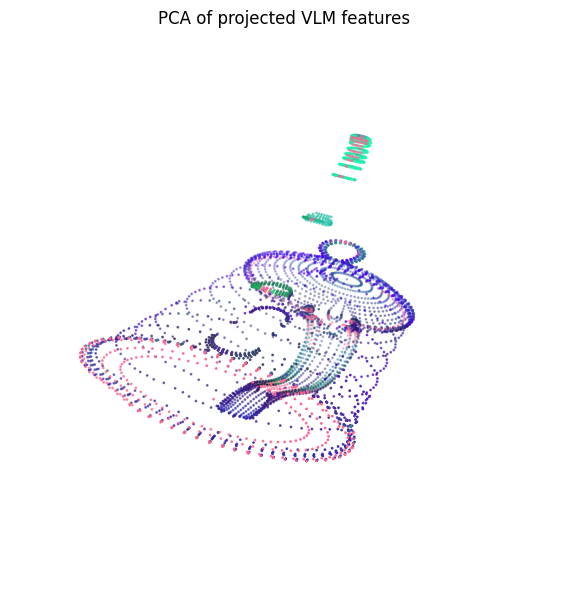

In [11]:
def show_colored_mesh(vertex_colors, title):
  colors = np.zeros((mesh.num_vertices, 4), dtype=np.uint8)
  colors[:, :3] = vertex_colors
  colors[:, 3] = 255
  colors[~vertex_sem.visible_in_any_view, 3] = 40
  tm = trimesh.Trimesh(vertices=mesh.vertices, faces=mesh.faces, vertex_colors=colors, process=False)
  fig = plt.figure(figsize=(6, 6))
  ax = fig.add_subplot(111, projection="3d")
  ax.scatter(tm.vertices[:, 0], tm.vertices[:, 1], tm.vertices[:, 2], c=colors[:, :3] / 255.0, s=1)
  ax.set_title(title)
  ax.set_axis_off()
  plt.tight_layout()
  plt.show()

pca_rgb = vertex_pca_colors(vertex_sem.features)
show_colored_mesh(pca_rgb, "PCA of projected VLM features")

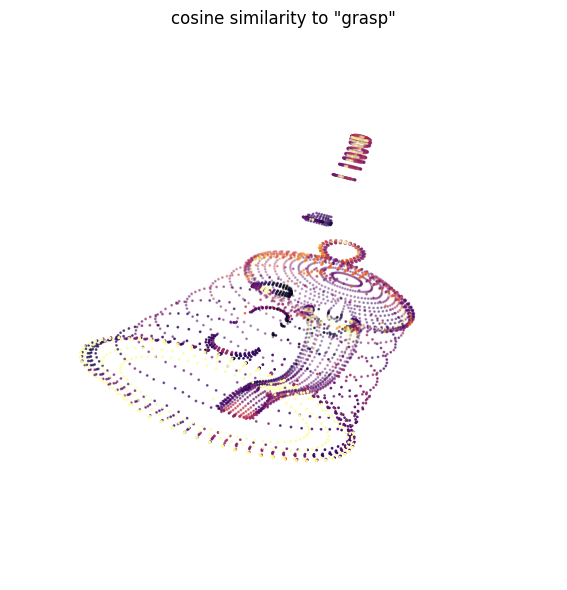

sim range on visible verts: -0.1498 .. -0.0411


In [12]:
text_emb, verbs = load_text_embeddings(vlm_cache / "text_embeddings.pt")
verb = "grasp" if "grasp" in verbs else verbs[0]
verb_idx = verbs.index(verb)
sim = vertex_verb_similarity(vertex_sem.features, text_emb[verb_idx])

sim_np = sim.numpy()
vis = vertex_sem.visible_in_any_view
lo, hi = sim_np[vis].min(), sim_np[vis].max()
norm = (sim_np - lo) / (hi - lo + 1e-8)
heat_rgb = (plt.cm.inferno(norm)[:, :3] * 255).astype(np.uint8)
show_colored_mesh(heat_rgb, f'cosine similarity to "{verb}"')
print(f"sim range on visible verts: {lo:.4f} .. {hi:.4f}")

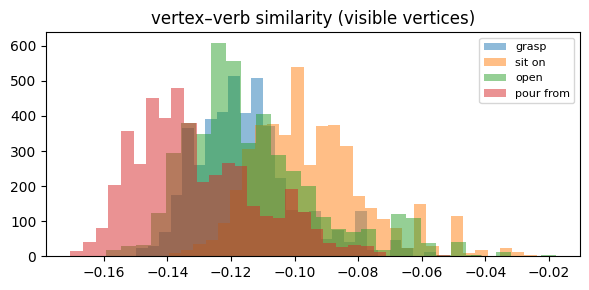

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
for i, v in enumerate(verbs):
    s = vertex_verb_similarity(vertex_sem.features, text_emb[i]).numpy()
    ax.hist(s[vis], bins=30, alpha=0.5, label=v)
ax.set_title("vertex–verb similarity (visible vertices)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
assert vertex_sem.features.shape == (mesh.num_vertices, D)
assert D == views[0].patches.feature_dim
assert vertex_sem.visible_in_any_view.mean() >= 0.10
assert vertex_sem.features[vertex_sem.visible_in_any_view].std() > 1e-3

pca_std = pca_rgb[vertex_sem.visible_in_any_view].std()
assert pca_std > 5.0, f"PCA colors too flat: {pca_std}"

sim_spread = sim_np[vis].max() - sim_np[vis].min()
assert sim_spread > 0.02, f"verb similarity too flat: {sim_spread}"

print("PASS: Step 5 projection")

PASS: Step 4 projection
